# EDA — Lead Scoring

## Checklist de trabajo
- [x] Tipeo de variables
- [ ] Lote 1: numéricas
- [ ] Lote 2: categóricas y booleanas
- [ ] Lote 3: alta cardinalidad
- [ ] Lote 4: texto
- [ ] Lote 5: fechas
- [ ] Consolidación y reporte


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_pickle("../02_datos/03_Entrenamiento/02_train_tablon_calidad.pkl")
print("shape:", df.shape)
display(df.dtypes.to_frame("dtype"))


shape: (6360, 23)


,dtype
id,int64
origen,object
fuente,object
no_enviar_email,object
no_llamar,object
compra,int64
visitas_total,float64
tiempo_en_site_total,int64
paginas_vistas_visita,float64
ult_actividad,object


## Recategorización aprobada de fuente
Se conservan las cuatro categorías principales y el resto se agrupa como `Otros`.


In [7]:
fuente_principales = ["Google", "Direct Traffic", "Chat", "Organic Search"]
df["fuente"] = df["fuente"].where(df["fuente"].isin(fuente_principales), "Otros")
print("Distribución de fuente después de agrupar:")
display(df["fuente"].value_counts())


Distribución de fuente después de agrupar:


fuente
Google            2017
Direct Traffic    1784
Chat              1225
Organic Search     804
Otros              530
Name: count, dtype: int64

## Unificación aprobada de ult_actividad
Se agrupan como `Otros` las categorías individuales con frecuencia menor al 2%.


In [8]:
umbral_ult_actividad = 0.02
freq_ult = df["ult_actividad"].value_counts(normalize=True, dropna=False)
categorias_ult_otros = freq_ult[freq_ult < umbral_ult_actividad].index.tolist()
df["ult_actividad"] = df["ult_actividad"].where(~df["ult_actividad"].isin(categorias_ult_otros), "Otros")
print("Categorías agrupadas:", categorias_ult_otros)
print("Distribución de ult_actividad después de agrupar:")
display(df["ult_actividad"].value_counts())


Categorías agrupadas: ['Form Submitted on Website', 'Desconocido', 'Unreachable', 'Unsubscribed', 'Had a Phone Conversation', 'Approached upfront', 'View in browser link Clicked', 'Email Marked Spam', 'Visited Booth in Tradeshow']
Distribución de ult_actividad después de agrupar:


ult_actividad
Email Opened               2371
SMS Sent                   1884
Chat Conversation           679
Page Visited on Website     435
Otros                       293
Converted to Lead           290
Email Bounced               219
Email Link Clicked          189
Name: count, dtype: int64

In [9]:
n = len(df)
high_card_threshold = max(50, 0.5 * np.sqrt(n))
discrete_threshold = min(20, 0.05 * n)
rows = []
for col in df.columns:
    s = df[col]
    nunique = s.nunique(dropna=True)
    missing_pct = s.isna().mean() * 100
    dtype = str(s.dtype)
    if pd.api.types.is_datetime64_any_dtype(s):
        kind = 'fecha'
    elif pd.api.types.is_numeric_dtype(s):
        integer_like = pd.api.types.is_integer_dtype(s) or (s.dropna() % 1 == 0).all()
        kind = 'numérica discreta' if integer_like and nunique <= discrete_threshold else 'numérica continua'
    else:
        avg_len = s.dropna().astype(str).str.len().mean() if s.notna().any() else 0
        uniqueness = nunique / max(1, s.notna().sum())
        if nunique > high_card_threshold and uniqueness > 0.5 and avg_len > 20:
            kind = 'texto'
        elif nunique > high_card_threshold:
            kind = 'alta cardinalidad'
        else:
            kind = 'categórica/booleana'
    rows.append({'columna': col, 'tipo': kind, 'dtype': dtype, 'n_unicos': nunique, 'missing_%': round(missing_pct, 2)})
typing = pd.DataFrame(rows)
display(typing)
print('Resumen por tipo:')
display(typing.groupby('tipo').size().reset_index(name='columnas'))
print('Alertas iniciales:')
alerts = []
for _, r in typing.iterrows():
    if r['missing_%'] > 20: alerts.append(f"{r['columna']}: missing {r['missing_%']}%")
    if r['n_unicos'] == 1: alerts.append(f"{r['columna']}: constante")
    if r['tipo'] == 'alta cardinalidad': alerts.append(f"{r['columna']}: alta cardinalidad ({r['n_unicos']})")
print('\n'.join(f'- {x}' for x in alerts) if alerts else '- Sin alertas automáticas')


,columna,tipo,dtype,n_unicos,missing_%
0,id,numérica continua,int64,6360,0.00
1,origen,categórica/booleana,object,4,0.00
2,fuente,categórica/booleana,object,5,0.00
3,no_enviar_email,categórica/booleana,object,2,0.00
4,no_llamar,categórica/booleana,object,2,0.00
5,compra,numérica discreta,int64,2,0.00
6,visitas_total,numérica continua,float64,31,0.00
7,tiempo_en_site_total,numérica continua,int64,1570,0.00
8,paginas_vistas_visita,numérica continua,float64,92,0.00
9,ult_actividad,categórica/booleana,object,8,0.00


Resumen por tipo:


,tipo,columnas
0,categórica/booleana,14
1,numérica continua,4
2,numérica discreta,5


Alertas iniciales:
- conociste_revista: constante
- conociste_periodico: constante
- conociste_youtube: constante
- score_actividad: missing 45.96%
- score_perfil: missing 45.96%


## Lote 2 — Categóricas y booleanas
Análisis estadístico y gráfico por variable. No se aplican transformaciones.


In [10]:
categoricas = typing.loc[typing["tipo"] == "categórica/booleana", "columna"].tolist()
cat_rows=[]
for c in categoricas:
    s=df[c].fillna("<NA>").astype(str)
    vc=s.value_counts()
    cat_rows.append({"columna":c,"n_categorias":int(s.nunique()),"missing_%":round(df[c].isna().mean()*100,2),"categoría_dominante":str(vc.index[0]),"dominante_%":round(vc.iloc[0]/len(s)*100,2),"raras_<1%":int((vc/len(s)<.01).sum())})
cat_stats=pd.DataFrame(cat_rows).sort_values("dominante_%",ascending=False)
display(cat_stats)
print("Detalle de frecuencias por variable:")
for c in categoricas:
    s=df[c].fillna("<NA>").astype(str)
    vc=s.value_counts().head(20).rename_axis("categoría").reset_index(name="registros")
    vc["porcentaje"]=(vc["registros"]/len(s)*100).round(2)
    print(f"\n{c}")
    display(vc)


,columna,n_categorias,missing_%,categoría_dominante,dominante_%,raras_<1%
8,conociste_revista,1,0.0,No,100.00,0
9,conociste_periodico,1,0.0,No,100.00,0
10,conociste_youtube,1,0.0,No,100.00,0
11,conociste_facebook,2,0.0,No,99.97,1
3,no_llamar,2,0.0,No,99.97,1
12,conociste_referencias,2,0.0,No,99.92,1
7,conociste_google,2,0.0,No,99.89,1
2,no_enviar_email,2,0.0,No,92.14,0
13,descarga_lm,2,0.0,No,67.97,0
6,ocupacion,7,0.0,Unemployed,59.72,3


Detalle de frecuencias por variable:

origen


,categoría,registros,porcentaje
0,Landing Page Submission,3407,53.57
1,API,2518,39.59
2,Lead Add Form,397,6.24
3,Lead Import,38,0.60



fuente


,categoría,registros,porcentaje
0,Google,2017,31.71
1,Direct Traffic,1784,28.05
2,Chat,1225,19.26
3,Organic Search,804,12.64
4,Otros,530,8.33


...

,categoría,registros,porcentaje
0,No,6358,99.97
1,Yes,2,0.03



conociste_referencias


,categoría,registros,porcentaje
0,No,6355,99.92
1,Yes,5,0.08



descarga_lm


,categoría,registros,porcentaje
0,No,4323,67.97
1,Yes,2037,32.03


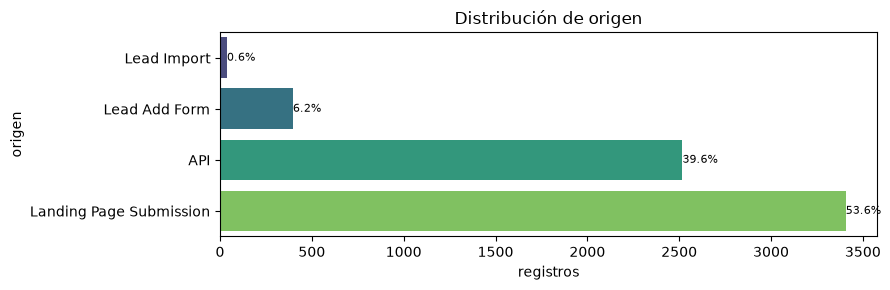

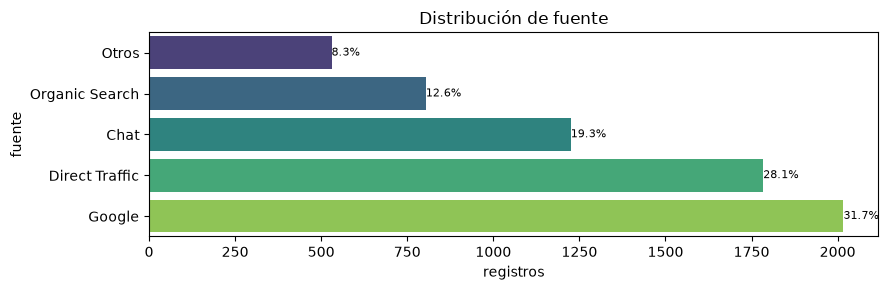

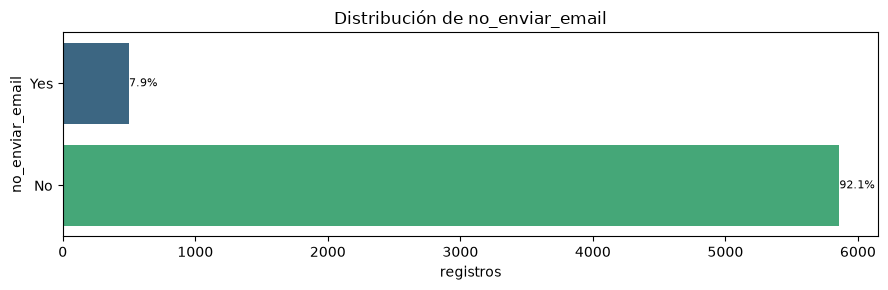

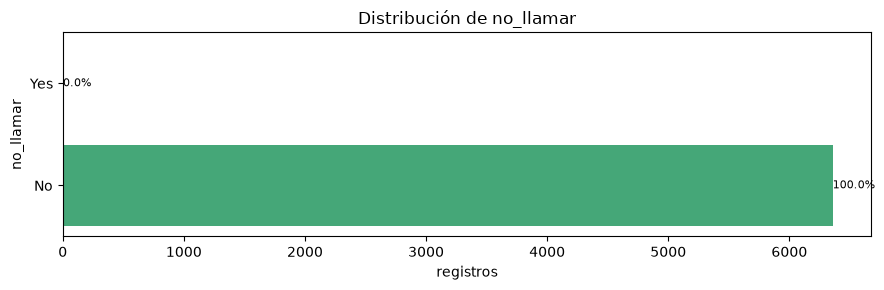

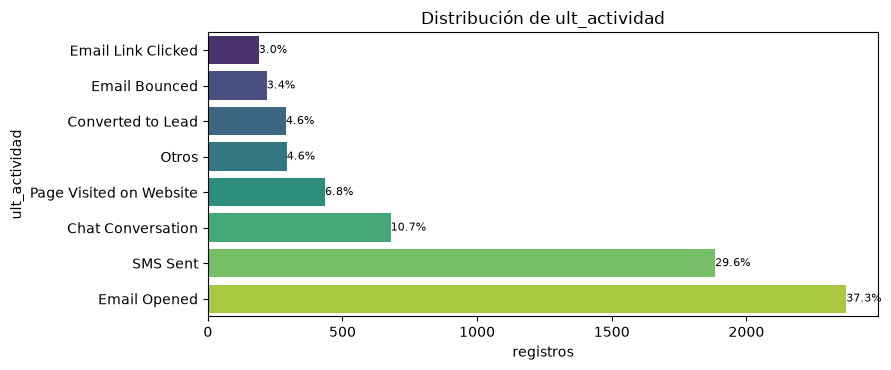

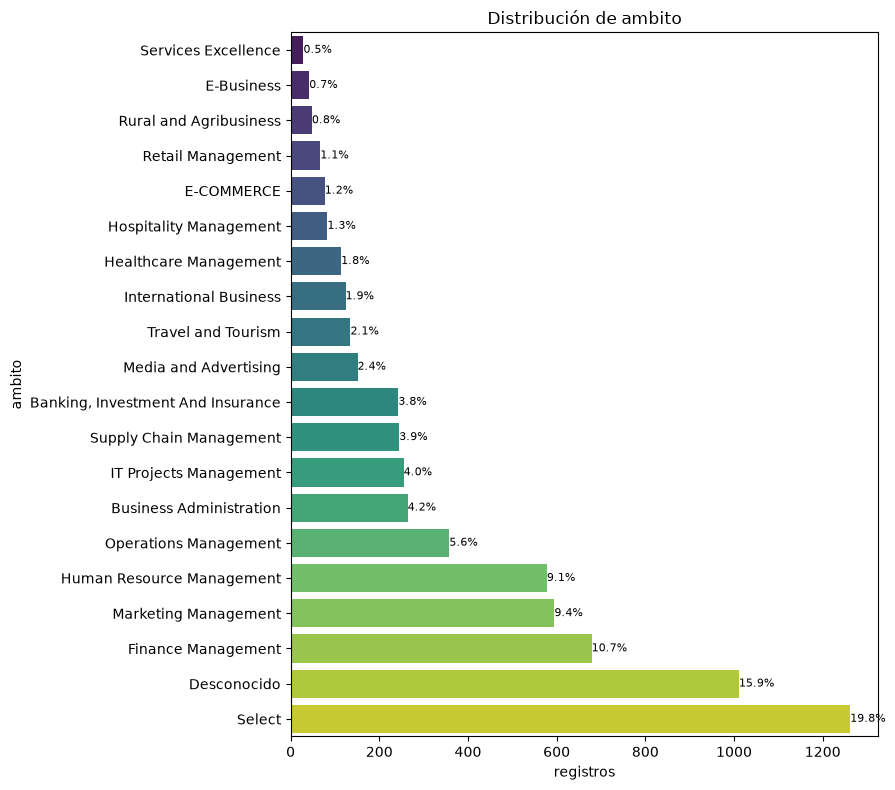

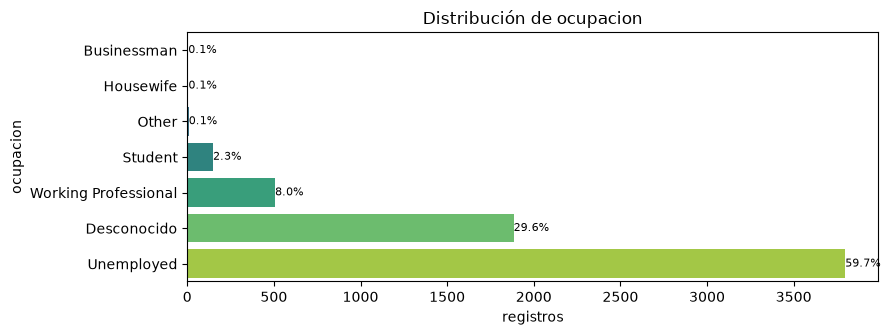

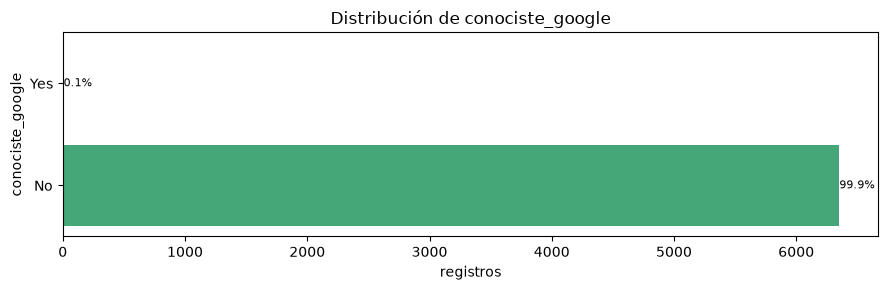

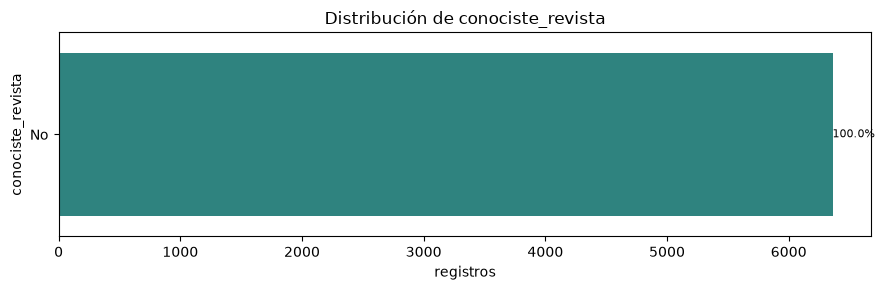

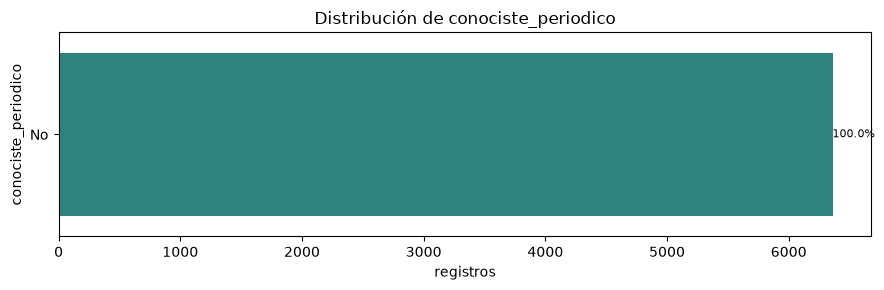

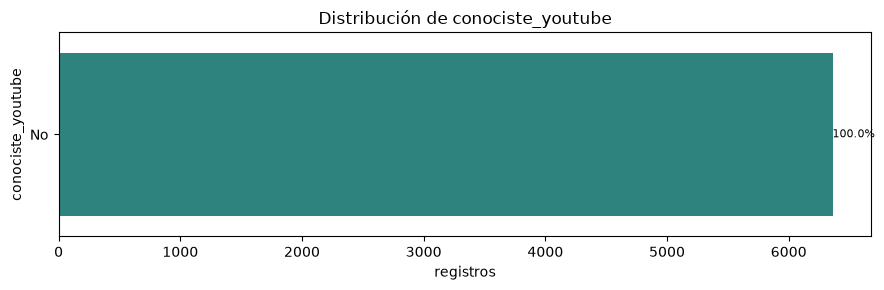

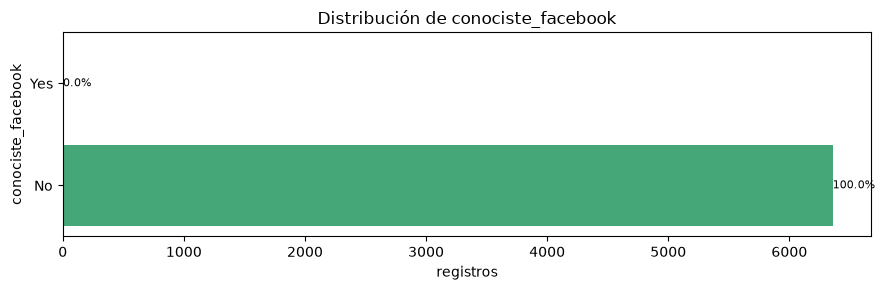

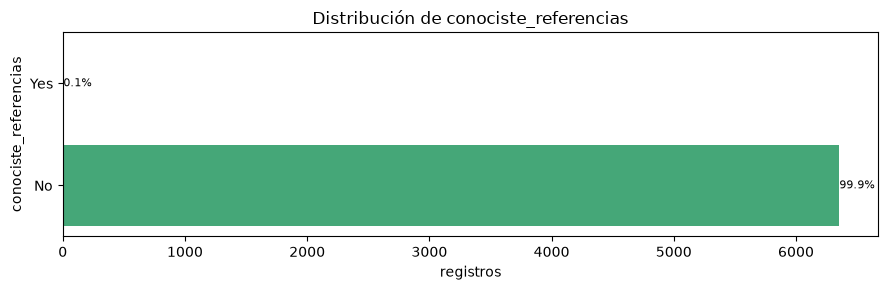

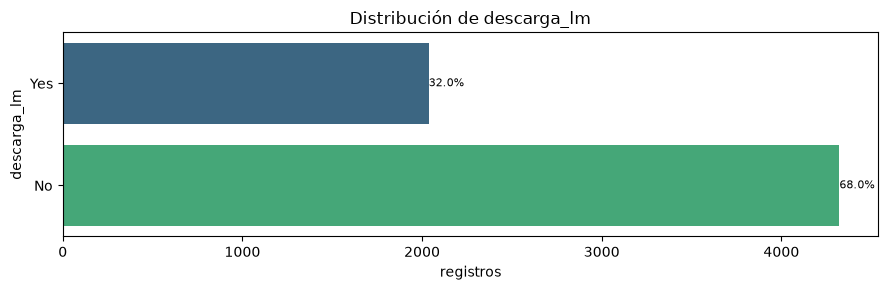

In [11]:
for c in categoricas:
    s=df[c].fillna("<NA>").astype(str)
    vc=s.value_counts().head(20).sort_values(ascending=True).reset_index()
    vc.columns=[c,"registros"]
    vc["porcentaje"]=vc["registros"]/len(s)*100
    plt.figure(figsize=(9, max(3, min(8, 0.35*len(vc)+1))))
    ax=sns.barplot(data=vc, x="registros", y=c, hue=c, legend=False, palette="viridis")
    for bar, pct in zip(ax.patches, vc["porcentaje"]):
        ax.annotate(f"{pct:.1f}%", (bar.get_width(), bar.get_y()+bar.get_height()/2), va="center", fontsize=8)
    plt.title(f"Distribución de {c}")
    plt.tight_layout()
    plt.show()


## Cierre del EDA
Persistencia del tablón EDA, reporte técnico y actualización del estado del proyecto.


In [ ]:
import io
from datetime import date

eda_dir = Path("../06_resultados/EDA")
eda_dir.mkdir(parents=True, exist_ok=True)
eda_pickle = Path("../02_datos/03_Entrenamiento/03_train_tablon_eda.pkl")
eda_report = eda_dir / "EDA_report.md"
df.to_pickle(eda_pickle)

info_buffer = io.StringIO()
df.info(buf=info_buffer)
info_text = info_buffer.getvalue()
type_counts = typing.groupby("tipo").size().to_dict()
report = f"""# Informe EDA — Lead Scoring

## Portada

- Dataframe: `df`
- Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas
- Fecha: {date.today().isoformat()}
- Variables numéricas discretas: {type_counts.get("numérica discreta", 0)}
- Variables numéricas continuas: {type_counts.get("numérica continua", 0)}
- Variables categóricas/booleanas: {type_counts.get("categórica/booleana", 0)}
- Variables de alta cardinalidad: {type_counts.get("alta cardinalidad", 0)}
- Variables de texto: {type_counts.get("texto", 0)}
- Variables fecha: {type_counts.get("fecha", 0)}

## Numéricas

- `compra` presenta una proporción positiva de 37,5%, con desbalance moderado.
- `visitas_total`, `paginas_vistas_visita` y `tiempo_en_site_total` tienen asimetría positiva.
- `score_actividad` y `score_perfil` son variables acotadas con 45,96% de faltantes estructurales.
- `id` es un identificador y no debe utilizarse como predictor.

## Categóricas y booleanas

- `fuente` quedó consolidada en `Google`, `Direct Traffic`, `Chat`, `Organic Search` y `Otros`.
- `ult_actividad` conserva las categorías principales y agrupa las categorías con frecuencia individual menor al 2% como `Otros`.
- `ambito` y `ocupacion` mantienen categorías `Desconocido` como información explícita de ausencia.
- `conociste_revista`, `conociste_periodico` y `conociste_youtube` son constantes; no se eliminaron durante el EDA.
- Algunas variables binarias son casi constantes y deberán evaluarse durante selección de variables.

## Alta cardinalidad

No se detectaron variables categóricas con más de 50 valores únicos. La máxima cardinalidad categórica fue `ambito`, con 20 categorías.

## Texto

No existen columnas de texto libre.

## Fechas

No existen columnas de fecha.

## Transformaciones aplicadas

1. En `fuente`, se conservaron las cuatro categorías principales y el resto se agrupó como `Otros`.
2. En `ult_actividad`, las categorías con frecuencia individual menor al 2% se agruparon como `Otros`.
3. No se eliminaron variables constantes ni se modificó `id`; la selección de variables queda para una fase posterior.

## Resumen global y alertas

- El dataset está concentrado en pocos canales de adquisición y acciones de actividad.
- Las variables de comportamiento presentan colas derechas.
- La ausencia de scores tiene significado de negocio y no debe interpretarse automáticamente como error.
- Las variables constantes y casi constantes pueden reducirse en la fase de selección de variables.
- Este EDA es principalmente univariante; el siguiente análisis recomendado es bivariante contra `compra`.

## Estructura final

```
{info_text}```
"""
eda_report.write_text(report, encoding="utf-8")

copilot_path = Path("../.github/copilot-instructions.md")
copilot = copilot_path.read_text(encoding="utf-8") if copilot_path.exists() else ""
section = f"""## ESTADO ACTUAL DEL PROYECTO

**Dataframe actual**: `../02_datos/03_Entrenamiento/03_train_tablon_eda.pkl`

**Estructura del dataframe**:
```
{info_text}```
"""
marker = "## ESTADO ACTUAL DEL PROYECTO"
if marker in copilot: copilot = copilot[:copilot.index(marker)].rstrip() + "\n\n" + section
else: copilot = copilot.rstrip() + "\n\n" + section
copilot_path.parent.mkdir(parents=True, exist_ok=True)
copilot_path.write_text(copilot, encoding="utf-8")
print("eda_pickle_saved:", eda_pickle.exists())
print("eda_report_saved:", eda_report.exists())
print("copilot_updated:", copilot_path.exists())
print("final_shape:", df.shape)
